# Auto-Encoder for Colorization

![Gray scale to color](notebook_images/colorization.png)

This notebook demonstrates how to use an autoencoder to perform the task of image colorization. The input will be a greyscale image, and the output should provide enough information to reconstruct a color RGB image.

Note, however, that colorization is inherently a predictive task rather than a reconstruction. Since a single grayscale image can correspond to many possible color images, the model is trained to predict plausible colors by leveraging contextual and semantic cues learned from large datasets. Hence, the output is a best guess, not necessarily a faithful recovery of the original colors.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm


# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

print(torch.__version__)

2.2.1+cu118


## Auxiliary functions

In [16]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}

    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets,classes,_) in tqdm(enumerate(train_loader, 0)):
            
            inputs = inputs.to(device)
            targets = targets.to(device)
    
            outputs = model(inputs)
    
            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.cpu().detach().numpy()
     
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i,t,_,_ in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t).cpu().detach().numpy()


        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Val Loss: {val_loss:0.6f}; Elapsed time: {(stop_time - start_time):0.4f}')

        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')
            best_val_loss = val_loss

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    
from matplotlib import colors

def plot_scatter(x,y,targets, lims = None):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    if lims != None:
        s = 50
    else: s = 1

    plt.figure(figsize=(10,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = s, norm=norm)
    plt.colorbar()
    if lims != None:
         plt.xlim(lims[0], lims[2])
         plt.ylim(lims[1], lims[3])

    plt.show()


def show_preds(set1, set2, set3, classes, count):
  
    columns = 5
    rows = count + 1  
    plt.figure(figsize=(count, .5 * rows * columns))
  
    for n in range(count):
        ax = plt.subplot(rows, columns, n*columns+1)
        plt.title(classes[n])
        plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+2)
        plt.title("A")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+3)
        plt.title("B")
        plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
        plt.axis('off')
        ax = plt.subplot(rows, columns, n*columns+4)
        plt.title("RGB")
        lab = np.stack(
            [
            (np.transpose(set1[n].numpy(), (1,2,0))[:,:,0] * 50 + 50), 
            (np.transpose(set2[n].numpy(), (1,2,0))[:,:,0] * 127),
            (np.transpose(set2[n].numpy(), (1,2,0))[:,:,1] * 127)
            ], 
            axis = 2)

        rgb = skimage.color.lab2rgb(lab)
        plt.imshow(rgb)
        plt.axis('off')

        ax = plt.subplot(rows, columns, n*columns+5)
        plt.title("Original")
        plt.imshow(set3[n].numpy())
        plt.axis('off')   

def show_images(set1, set2, original, classes, count):
  
  columns = 4
  rows = count + 1  
  plt.figure(figsize=(count, 0.5 * columns * rows))
  
  for n in range(count):

    ax = plt.subplot(rows, columns, n*columns+1)
    plt.title(classes[n])
    plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')

    ax = plt.subplot(rows, columns, n*columns+2)
    plt.title("A")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,0], cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')

    ax = plt.subplot(rows, columns, n*columns+3)
    plt.title("B")
    plt.imshow(np.transpose(set2[n].numpy(), (1,2,0))[:,:,1], cmap=plt.cm.gray, vmin=-1, vmax=1)
    plt.axis('off')  
                
    ax = plt.subplot(rows, columns, n*columns+4)
    plt.title("Original")
    plt.imshow(original[n].numpy())
    plt.axis('off')   


# Configuration

In [3]:
HEIGHT = 256
WIDTH = 256
NUM_CHANNELS = 3
BATCH_SIZE = 32
LATENT_SPACE_DIM = 256

MODEL_PATH = 'autoencoder_colorization_models'

# defines if training, or using already pre-trained models. Set to TRUE in the first run 
# of this notebook, and FALSE for subsequent runs
TRAIN = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# The Dataset

## Natural-Color Dataset (NCD)

The Natural-Color Dataset (NCD) is an image colorization dataset containing 723 images, spanning 20 categories of vegetables/fruits, with each image featuring a single vegetable/fruit type on a white background. 

[Dataset download from Kaggle](https://www.kaggle.com/datasets/tyrionlannisterlzy/natural-color-dataset-for-colorization-task)



# CIELAB Color Space

The CIELAB color space, aka Lab*, is a three-dimensional, device-independent color model designed to approximate human vision. It represents colors with three components: 

- L* for lightness (ranging from black at 0 to white at 100); 
- a* for the green–red axis (negative values toward green, positive toward red)
- b* for the blue–yellow axis (negative values toward blue, positive toward yellow). 

The a* and b* channels have values typically in the range -128 to 127, or -100 to 100, depending on the implementation. In scikit-image (skimage) the range is -128 to 127. 

LAB covers the entire range of colors visible to humans and is nearly perceptually uniform, meaning that equal changes in values correspond to roughly equal perceived color differences. 
 
![CIELAB](./notebook_images/CIELAB.jpg)

Image from [here](https://www.researchgate.net/publication/332013468_ORTHO_IMAGE_CLASSIFICATION_OF_BENTHIC_HABITATS_IN_HINATUAN_SURIGAO_DEL_SUR_PHILIPPINES_USING_CIELAB_COLOR_CONSTANCY_AND_INTESITY_AS_FEATURES/figures?lo=1)

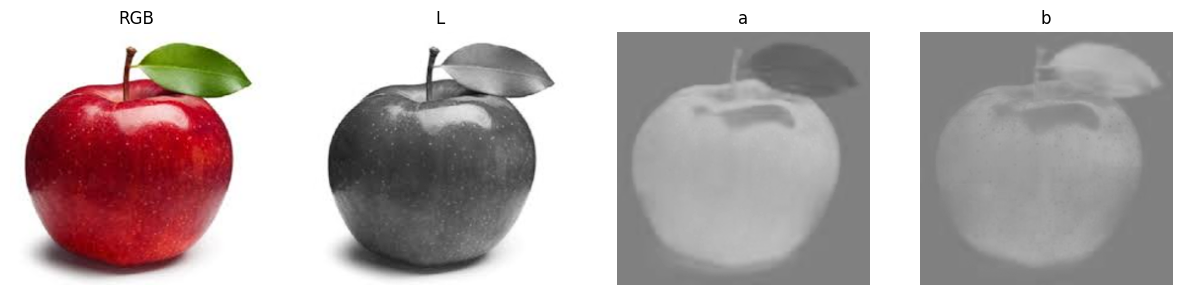

In [ ]:
def showLAB(filename):
    
    img = Image.open(filename).resize([WIDTH, HEIGHT]).convert('RGB')
    LAB = skimage.color.rgb2lab(np.array(img)).astype(np.float32)

    plt.figure(figsize=(15, 60))

    ax = plt.subplot(1,4,1)
    plt.title("RGB")
    plt.imshow(img)
    plt.axis('off')
    
    ax = plt.subplot(1,4,2)
    plt.title("L")
    plt.imshow(LAB[:,:,0], cmap='gray', vmin=0, vmax=100)
    plt.axis('off')
    
    ax = plt.subplot(1,4,3)
    plt.title("a")
    plt.imshow(LAB[:,:,1], cmap='gray', vmin=-128, vmax=127)
    plt.axis('off')

    ax = plt.subplot(1,4,4)
    plt.title("b")
    plt.imshow(LAB[:,:,2], cmap='gray', vmin=-128, vmax=127)
    plt.axis('off')


showLAB( f'data/NCD/Color/Apple/Apple3.jpg')    

# Create Dataset

To create the dataset we first convert all images to the LAB color space. The $L$ channel is used as the model input, while the $a$ and $b$ serve as the prediction targets.

This approach allows the model to focus only in predicting the colour information, without the need to reconstruct the luminance.

This is a common approach, as there are no datasets of pairs of true greyscale and RGB images.

However, it’s important to note that this method can introduce a color shift, as the $L$ channel from LAB does not exactly correspond to a standard grayscale image.

Some approaches to deal with this issue by converting the greyscale image to LAB, first creating an RGB image stacking the greyscale values across all three channels. Yet, even with this method, there is no guarantee that the $L$ channel obtained from a color RGB image will match the $L$ channel derived from its greyscale version.

To create the dataset a subclass of Dataset will be implemented. Since the dataset is fairly small the entire dataset will be loaded into memory as this will speed up training.

In addition to storing the $L$ and color channels, the dataset will also retain the class name and the original color image. These are included for visualization purposes only. 

In [ ]:
class CustomDataLoader(torch.utils.data.Dataset):

    def __init__(self, path, transform = None):
        super().__init__()
        
        self.path = path

        self.transform = transform
        self.classes = [x.name for x in os.scandir(path) if x.is_dir()]
        self.classes_to_idx = {cls_name:i for i, cls_name in enumerate(self.classes)}
        self.paths = list(pathlib.Path(path,).glob('*/*.jpg'))
        self.data = []
        self.labels = []
        for p in self.paths:
           
                img = Image.open(p).resize([WIDTH, HEIGHT]).convert('RGB')
                class_name  = p.parent.name
                lab = skimage.color.rgb2lab(np.array(img)).astype(np.float32)

                l = (lab[:, :, 0:1]/50.0) - 1   # (H, W, 1)
                ab = lab[:, :, 1:]/127.0   # (H, W, 2)

                self.data.append([l, ab, class_name, np.array(img)])

    def __len__(self):
        return len(self.paths)    

    def __getitem__(self, idx):
        dat = self.data[idx]
        return self.transform(dat[0]), self.transform(dat[1]), dat[2] , dat[3]


**Dataset partitioning**

As there is no standard partition for this dataset, we opted for a random split with:

- 70% for training
- 20% for validation
- 10% for testing


In [6]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

dataset = CustomDataLoader('data/NCD/Color', transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size 

train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

Displaying some samples of the dataset

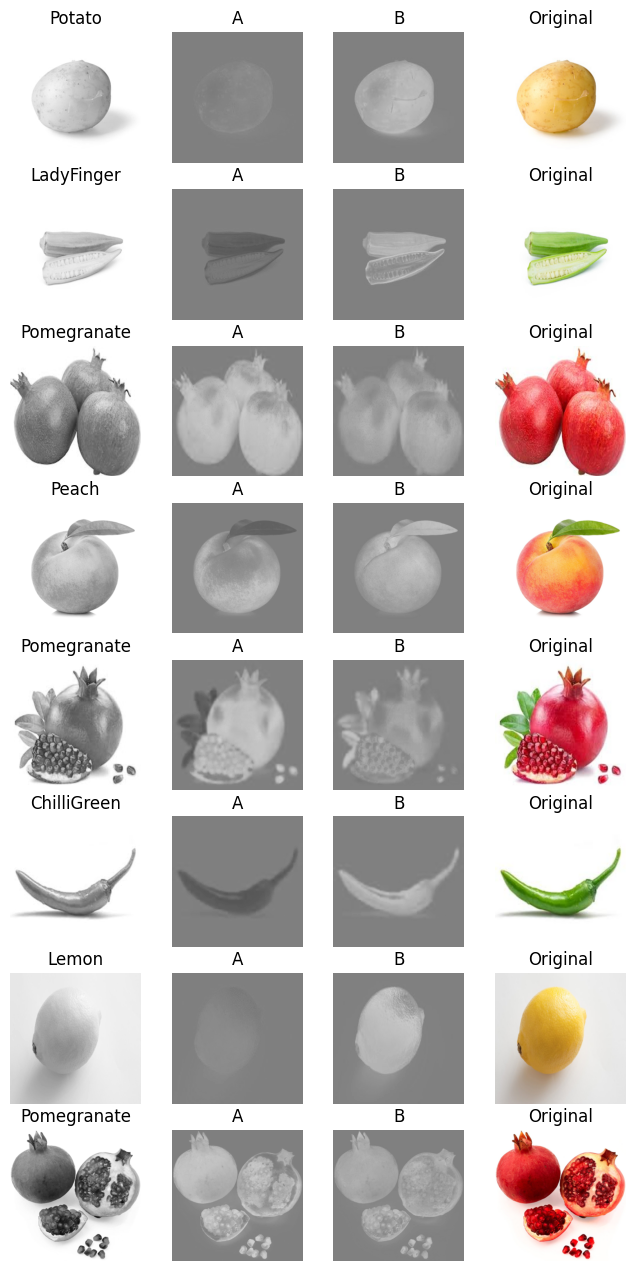

In [17]:
gray, AB, classes, original = next(iter(train_loader))

show_images(gray,AB, original, classes, 8)


# Architecture

In [24]:
class Conv_Block(nn.Module):

    def __init__(self, in_channels, out_channels):
        
        super().__init__()

        self.convBlock = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding = 1, stride = 2), 
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


    def forward(self, x):
        return self.convBlock(x)      
   

class Up_Conv_Block(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upConvBlock = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size= 3, stride = 2, 
                               padding=1, output_padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.upConvBlock(x)      


class AutoEncoder(torch.nn.Module):

    def __init__(self, latent_space_dim):
        super().__init__()

        #encoder
        self.encode = nn.Sequential(
                Conv_Block(1,32), # 128x128
                Conv_Block(32,64), # 64x64      
                Conv_Block(64,128), # 32x32
                Conv_Block(128,256), # 16x16      
                Conv_Block(256,512) # 8x8
        )
        self.efc = nn.Linear(512*8*8, latent_space_dim)    

        #decoder layers
        self.dfc1 = nn.Linear(latent_space_dim, 512*8*8)
        self.decode = nn.Sequential(
                Up_Conv_Block(512, 256),
                Up_Conv_Block(256, 128),
                Up_Conv_Block(128, 64),
                Up_Conv_Block(64, 32)
        )
        self.dfc2 = nn.ConvTranspose2d(in_channels = 32, out_channels = 2, 
                                                kernel_size= 3, stride = 2, 
                                                padding = 1, output_padding = 1)
        self.sig = nn.Sigmoid()



    def encoder(self, x):
        x = self.encode(x)
        x = torch.flatten(x,1)
        return self.efc(x)

    def decoder(self,x):
       x = self.dfc1(x)
       x = x.reshape(-1, 512, 8, 8)
       x = self.decode(x)
       x = self.dfc2(x)
       return x

    def forward(self,x):

        encoded = self.encoder(x)
        output = self. decoder(encoded)
        return self.sig(output)   

In [25]:
AE = AutoEncoder(LATENT_SPACE_DIM)
AE.to(device)
torchinfo.summary(AE, input_size=(BATCH_SIZE, 1, WIDTH, HEIGHT))

Layer (type:depth-idx)                        Output Shape              Param #
AutoEncoder                                   [32, 2, 256, 256]         --
├─Sequential: 1-1                             [32, 512, 8, 8]           --
│    └─Conv_Block: 2-1                        [32, 32, 128, 128]        --
│    │    └─Sequential: 3-1                   [32, 32, 128, 128]        384
│    └─Conv_Block: 2-2                        [32, 64, 64, 64]          --
│    │    └─Sequential: 3-2                   [32, 64, 64, 64]          18,624
│    └─Conv_Block: 2-3                        [32, 128, 32, 32]         --
│    │    └─Sequential: 3-3                   [32, 128, 32, 32]         74,112
│    └─Conv_Block: 2-4                        [32, 256, 16, 16]         --
│    │    └─Sequential: 3-4                   [32, 256, 16, 16]         295,680
│    └─Conv_Block: 2-5                        [32, 512, 8, 8]           --
│    │    └─Sequential: 3-5                   [32, 512, 8, 8]           1,181,184

# Training

In [26]:
if TRAIN:
    opt = torch.optim.Adam(AE.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                               factor = 0.1, patience=3)
    loss_fn = torch.nn.loss_fn = torch.nn.MSELoss()
    early_stop = Early_Stopping(9)
        
    history=train(AE, train_loader, val_loader, 100, loss_fn, opt,  scheduler, early_stop, 
                      f'{MODEL_PATH}/color_ae' )

16it [00:00, 18.86it/s]


Epoch: 000; Loss: 0.005621; Val Loss: 0.006430; Elapsed time: 0.9415


16it [00:00, 43.80it/s]


Epoch: 001; Loss: 0.003473; Val Loss: 0.003874; Elapsed time: 0.4376


16it [00:00, 42.34it/s]


...

==> Learning rate updated:  0.0001  ->  1e-05
Epoch: 034; Loss: 0.000267; Val Loss: 0.000539; Elapsed time: 0.4243


16it [00:00, 43.15it/s]


Epoch: 035; Loss: 0.000263; Val Loss: 0.000539; Elapsed time: 0.4374


16it [00:00, 43.48it/s]


Epoch: 036; Loss: 0.000259; Val Loss: 0.000546; Elapsed time: 0.4313
Early stopping!
Finished Training


In [32]:
reload = torch.load(f'{MODEL_PATH}/color_ae_best.pt')
print(reload['epoch'])
model = AutoEncoder(LATENT_SPACE_DIM)
model.to(device)
model.load_state_dict(reload['model'])

26


<All keys matched successfully>

# Evaluation

Since the goal of a colorization model is to generate plausible rather than faithful color reconstructions, evaluation becomes fundamentally different from standard image restoration tasks. Since there is no single "correct" colorization for a given grayscale image, traditional pixel-wise metrics like MSE or PSNR are often insufficient or misleading.

Truly evaluating colorization models requires a combination of perceptual metrics, human studies, and, in some cases, task-based assessments. No single metric perfectly captures plausibility, so a multi-faceted evaluation is recommended

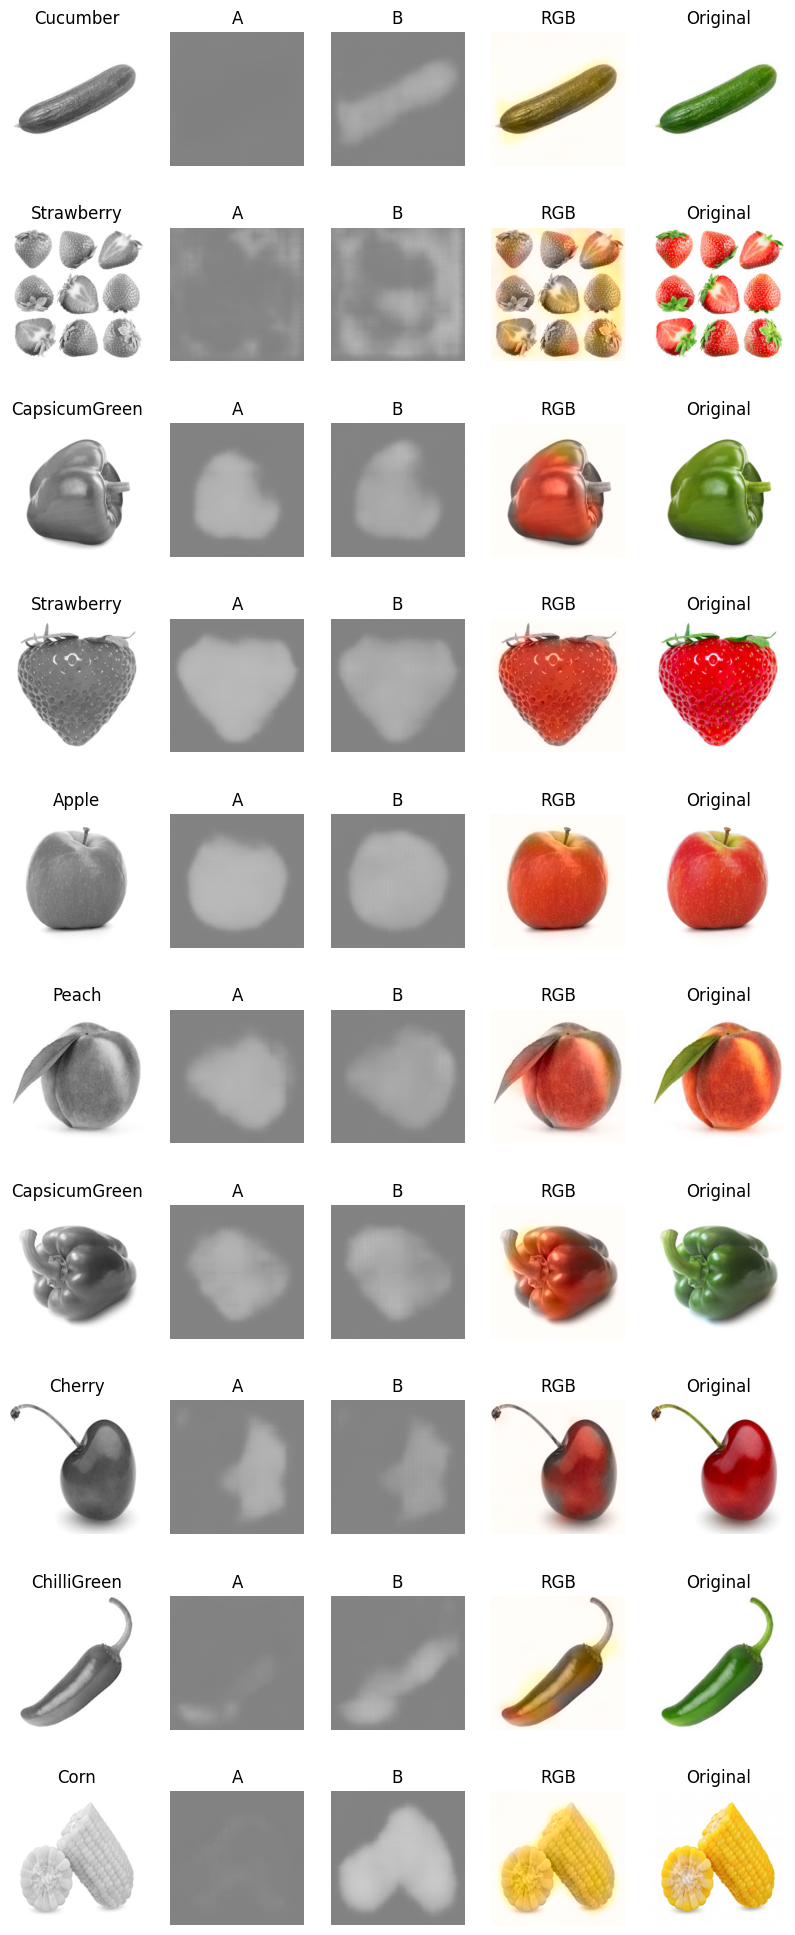

In [41]:
i, t, c, o = next(iter(test_loader))
recon = AE(i.to(device)).cpu().detach()
    
show_preds(i, recon, o, c, 10)